
# Mapping Land Surface Temperature for UK cities

<span class="badge science">Science</span>
<span class="badge climate">Climate</span>

## Description & purpose
This tutorial demonstrates how to access **EOCIS Land Surface Temperature (LST) from Sentinel 3A/3B** data from the Earth Observation Data Hub (EODH) using the `pyeodh` Python client. It covers catalogue searching, loading in cloud-optimised assets, and performing reprojection for mapping the data over national and city scales to produce interactive and static visualisations.


## Setup 📦

Ensure the required Python libraries are available.  
This includes the `pyeodh` client for interacting with the EODH data catalogue.


In [19]:
# Run this cell if pyeodh is not installed, or needs updating
get_ipython().system('pip install --upgrade pyeodh')
get_ipython().system('pip install folium shapely xarray fsspec rioxarray cartopy pyproj')

import pyeodh
import cartopy.crs as ccrs
import folium
import fsspec
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray
import shapely as sh
import xarray as xr
from pyproj import Transformer
from shapely.geometry import Point


## Connect to the EODH 🔗
We first create an instance of the Python client and connect to the catalogue service.
A time range and spatial extent are also defined for use throughout the analysis.

In [2]:
# Connect to the Hub
client = pyeodh.Client(base_url="https://eodatahub.org.uk").get_catalog_service()

# Define temporal and spatial range for the collection search
time_start = "2024-08-01"
time_end   = "2024-08-31"
lon_range  = [-8.18, 2.09]
lat_range  = [49.67, 61.06]

## Search the catalogue 🔍
The EODH catalogue can be searched programmatically using dataset identifiers and metadata filters.
Here we search for Daily Sentinel‑3B Land Surface Temperature products within the selected time window, using the `eocis-lst-s3b-day` identifier.

In [3]:
datasearch = client.search(
    collections=["eocis-lst-s3b-day"],
    catalog_paths=["public/catalogs/ceda-stac-catalogue"],
    start_datetime=time_start,
    end_datetime=time_end,
)

Each search result may contain multiple assets.
Where available, Kerchunk reference files are preferred, as they allow efficient remote access to NetCDF datasets without downloading the full data volume.

In [4]:
list_of_data = []
for item in datasearch:
    asset = None

    if "reference_file" in item.assets:
        asset = item.assets["reference_file"]
        href = asset.href
        is_kerchunk = True
    else:
        for k, a in item.assets.items():
            if "data" in a.roles or a.type == "application/netcdf":
                asset = a
                href = asset.href
                is_kerchunk = False
                break

    if is_kerchunk:
        list_of_data.append(href)
    else:
        print("nc")

## Load in the data 🌐
The collected Kerchunk references are opened using xarray to create a single combined dataset, enabling time‑aware and spatial operations.

In [6]:
ds = xr.open_mfdataset(list_of_data, engine="kerchunk")
ds

<xarray.Dataset> Size: 3TB
Dimensions:          (time: 31, lat: 18000, lon: 36000, channel: 2,
                      length_scale: 1)
Coordinates:
  * channel          (channel) float64 16B 11.0 12.0
  * lat              (lat) float32 72kB -90.0 -89.99 -89.98 ... 89.98 89.99
  * lon              (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0
  * time             (time) datetime64[ns] 248B 2024-08-01 ... 2024-08-31
Dimensions without coordinates: length_scale
Data variables: (12/18)
    dtime            (time, lat, lon) timedelta64[ns] 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    emis             (time, channel, lat, lon) float64 321GB dask.array<chunksize=(1, 2, 1000, 1000), meta=np.ndarray>
    lcc              (time, lat, lon) float32 80GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    lst              (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    lst_unc_loc_atm  (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    lst_unc_loc_sfc  (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    ...               ...
    qual_flag        (time, lat, lon) float32 80GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    sataz            (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    satze            (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    solaz            (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    solze            (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
    t2m              (time, lat, lon) float64 161GB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>
Attributes: (12/42)
    Conventions:                CF-1.8
    cdm_data_type:              grid
    code_version:               c5aa81266e41108e98b6c379249ffe0676996634
    comment:                    These data were produced as part of the EOCIS...
    creator_email:              djg20@le.ac.uk
    creator_name:               University of Leicester Surface Temperature G...
    ...                         ...
    summary:                    This file contains level L3C global land surf...
    time_coverage_duration:     P1D
    time_coverage_end:          20240801T235959Z
    time_coverage_resolution:   P1D
    time_coverage_start:        20240801T000000Z
    title:                      EOCIS land surface temperature data at produc...

Here we slice the dataset by subsetting the array to a UK bounding box, using latitude and longitude coordinates we defined earlier.
This reduces the amount of data we are dealing with, storing only what we need for the visualisation.

In [7]:
cutout = ds.sel(
    lon=slice(lon_range[0], lon_range[1]),
    lat=slice(lat_range[0], lat_range[1])
)

Additional spatial subsets are defined for UK cities. 🏙️

In [8]:
sub_1 = ds.sel(lon=slice(-0.489, 0.236), lat=slice(51.28, 51.686))
sub_2 = ds.sel(lon=slice(-2.05, -1.57), lat=slice(52.38, 52.60))
sub_3 = ds.sel(lon=slice(-2.3197, -2.1458), lat=slice(53.3392, 53.5447))
sub_4 = ds.sel(lon=slice(-3.35, -3.05), lat=slice(51.37, 51.57))
sub_5 = ds.sel(lon=slice(-4.40, -4.08), lat=slice(55.77, 55.95))
sub_6 = ds.sel(lon=slice(-3.52, -3.03), lat=slice(55.82, 56.03))

## Pre-processing the data
Here we calculate a time‑averaged Land Surface Temperature field, to reduce the array dimensions for visualisation.
Invalid or missing values are masked.

In [9]:
import numpy as np

masked_array = np.ma.array(
    np.flip(cutout["lst"].mean(dim=["time"]).values, axis=0),
    mask=np.isnan(np.flip(cutout["lst"].mean(dim=["time"]).values, axis=0))
)

In [10]:
import matplotlib

cmap = matplotlib.colormaps["inferno"]
cmap.set_bad('white', 0.)
plt.imsave("lst_uk.png", masked_array, cmap=cmap, format="png")

## Interactive map of Land Surface Temperature (LST) 🌡️
Using Folium, we plot an interactive map to help us explore the spatial distribution of temperature anomalies across the UK.


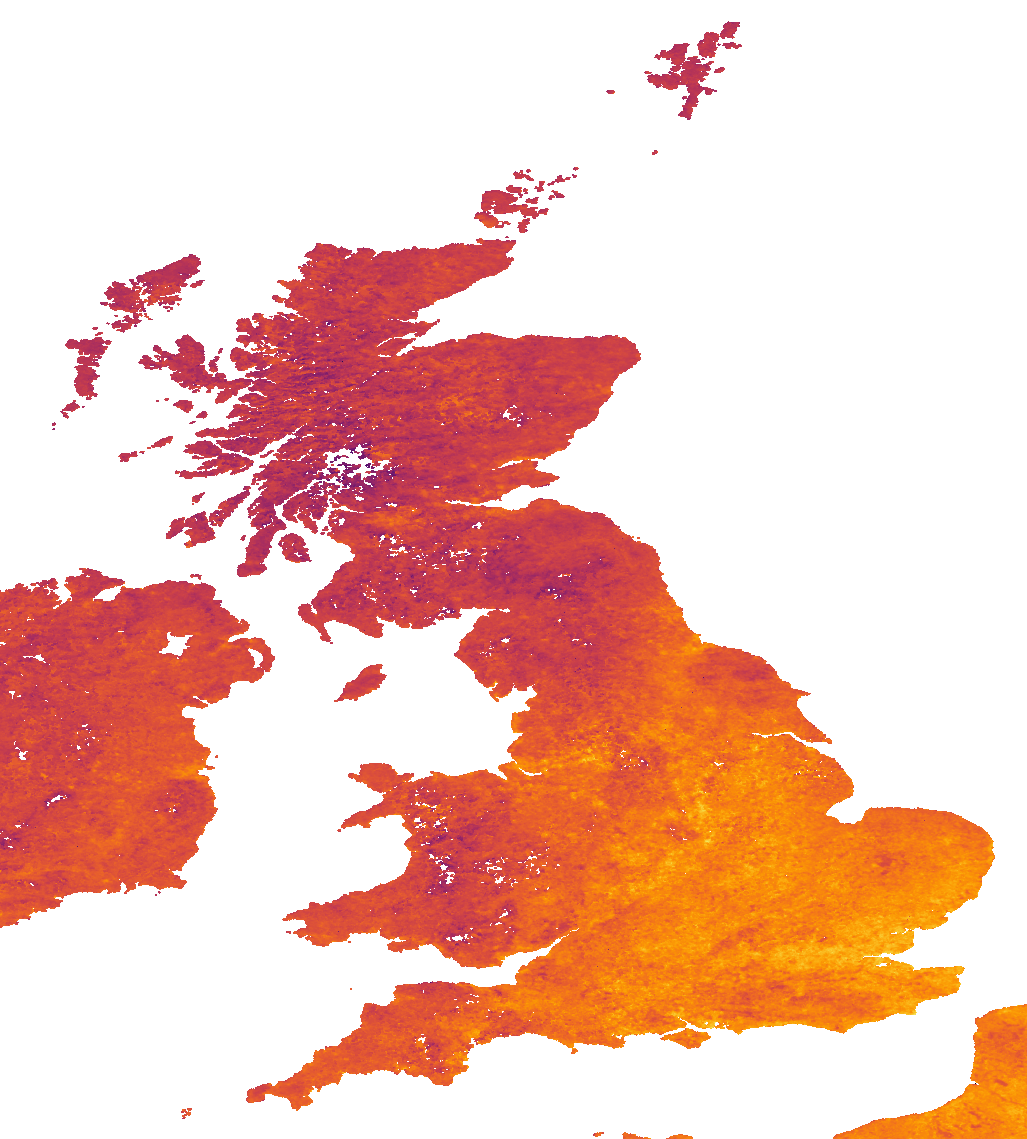

In [18]:
from matplotlib import cm

m = folium.Map(
    location=(51, 0),
    control_scale=True,
)

dat_img = folium.raster_layers.ImageOverlay(image = "lst_uk.png", bounds=[[lat_range[1],lon_range[0]],[lat_range[0],lon_range[1]]], opacity=0.5,name="LST")
dat_img.add_to(m)

folium.LayerControl().add_to(m) # this allows turning layers off and on
m.add_child(
    folium.LatLngPopup()
)
m

## Reprojection 🔄
For UK‑specific analysis, the data are reprojected from geographic coordinates (EPSG:4326) to the British National Grid (EPSG:27700).

In [14]:
sub_1_in = sub_1["lst"].mean(dim=["time"])   # already in EPSG:4326
sub_1_in2 = sub_1_in.rio.write_crs("EPSG:4326", inplace=False)
sub1 = sub_1_in2.rio.reproject("EPSG:27700")
sub1 = sub1.where(sub1 < 400)

sub_2_in = sub_2["lst"].mean(dim=["time"])   # already in EPSG:4326
sub_2_in2 = sub_2_in.rio.write_crs("EPSG:4326", inplace=False)
sub2 = sub_2_in2.rio.reproject("EPSG:27700")
sub2 = sub2.where(sub2 < 400)

sub_3_in = sub_3["lst"].mean(dim=["time"])   # already in EPSG:4326
sub_3_in2 = sub_3_in.rio.write_crs("EPSG:4326", inplace=False)
sub3 = sub_3_in2.rio.reproject("EPSG:27700")
sub3 = sub3.where(sub3 < 400)

sub_4_in = sub_4["lst"].mean(dim=["time"])   # already in EPSG:4326
sub_4_in2 = sub_4_in.rio.write_crs("EPSG:4326", inplace=False)
sub4 = sub_4_in2.rio.reproject("EPSG:27700")
sub4 = sub4.where(sub4 < 400)

sub_5_in = sub_5["lst"].mean(dim=["time"])   # already in EPSG:4326
sub_5_in2 = sub_5_in.rio.write_crs("EPSG:4326", inplace=False)
sub5 = sub_5_in2.rio.reproject("EPSG:27700")
sub5 = sub5.where(sub5 < 400)

sub_6_in = sub_6["lst"].mean(dim=["time"])   # already in EPSG:4326
sub_6_in2 = sub_6_in.rio.write_crs("EPSG:4326", inplace=False)
sub6 = sub_6_in2.rio.reproject("EPSG:27700")
sub6 = sub6.where(sub6 < 400)

In [15]:
lst_in = cutout["lst"].mean(dim=["time"])   # already in EPSG:4326
lst_in2 = lst_in.rio.write_crs("EPSG:4326", inplace=False)
lst = lst_in2.rio.reproject("EPSG:27700")
lst = lst.where(lst < 400)


proj = ccrs.OSGB()  # map projection = EPSG:4326

## Static plots of Land Surface Temperature (LST) 🌡️
The final figure presents a UK‑wide average Land Surface Temperature map, suitable for reporting or research papers.

Text(0.5, 1.0, 'Edinburgh')

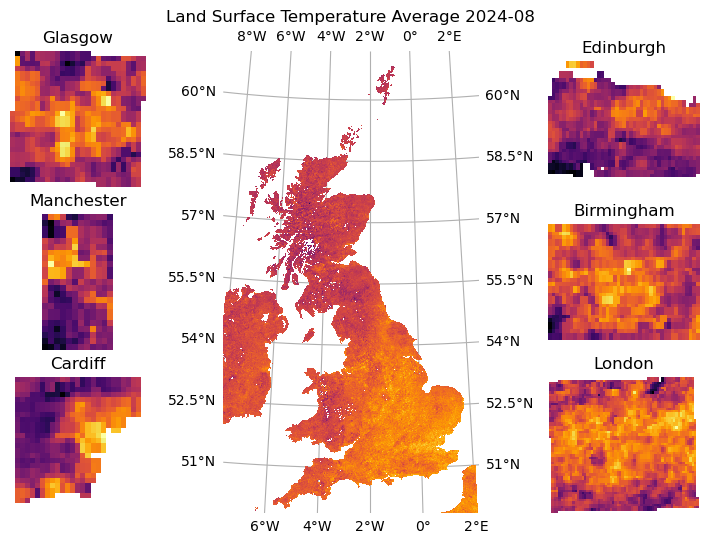

In [17]:
mosaic = [["a", "b", "b","c"], ["d", "b", "b","e"], ["f", "b", "b","g"]]
# Define specific projections for labels 'A' and 'C'
per_subplot_kw = {
    "a": {"projection": proj},
    "b": {"projection": proj},
    "c": {"projection": proj},
    "d": {"projection": proj},
    "e": {"projection": proj},
    "f": {"projection": proj},
    "g": {"projection": proj}
}



fig, axs = plt.subplot_mosaic(figsize=(9, 6), mosaic=mosaic, per_subplot_kw=per_subplot_kw)
axs["a"].axis('off')
axs["b"].axis('off')
axs["c"].axis('off')
axs["d"].axis('off')
axs["e"].axis('off')
axs["f"].axis('off')
axs["g"].axis('off')
#axs["b"] = plt.axes(projection=proj)
axs["b"].gridlines(draw_labels=True,zorder=0)
mesh = lst.plot(
    ax=axs["b"],
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)
axs["b"].set_title("Land Surface Temperature Average 2024-08")



#axs["g"] = plt.axes(projection=proj)
#axs["g"].gridlines(draw_labels=True,zorder=0)

sub_1_mesh = sub1.plot(
    ax=axs["g"],
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)
axs["g"].set_title("London")

sub_3_mesh = sub3.plot(
    ax=axs["d"],
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)
axs["d"].set_title("Manchester")

sub_2_mesh = sub2.plot(
    ax=axs["e"],
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)
axs["e"].set_title("Birmingham")

sub_4_mesh = sub4.plot(
    ax=axs["f"],
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)
axs["f"].set_title("Cardiff")

sub_5_mesh = sub5.plot(
    ax=axs["a"],
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)
axs["a"].set_title("Glasgow")

sub_6_mesh = sub6.plot(
    ax=axs["c"],
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)
axs["c"].set_title("Edinburgh")


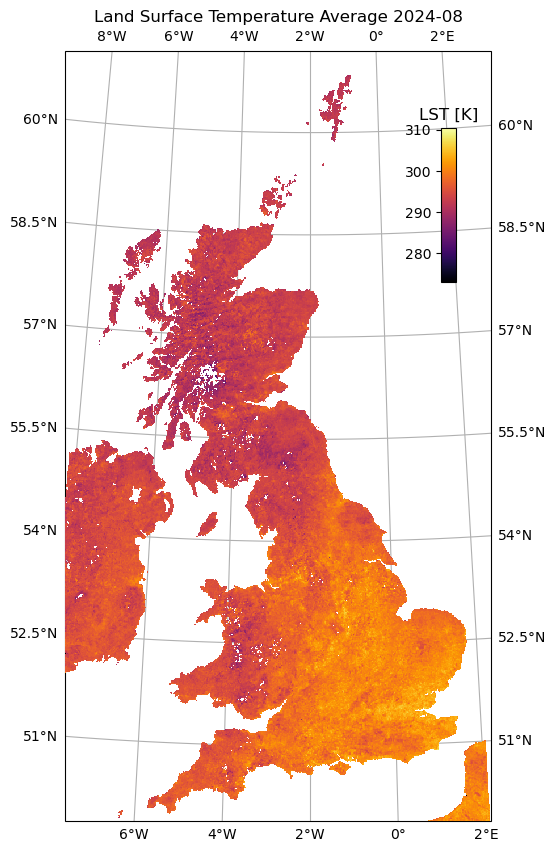

In [16]:
# Extract SST variable
plt.figure(figsize=(10,10))
ax = plt.axes(projection=proj)
ax.gridlines(draw_labels=True,zorder=0)
mesh = lst.plot(
    ax=ax,
    transform=proj,   # IMPORTANT: matches data CRS
    cmap="inferno",
    add_colorbar=False,
    #cbar_kwargs={"label": "Land Surface Temperature (°C)"}
    zorder=3
)

ax_ins = ax.inset_axes([0.7, 0.7, 0.2, 0.2], projection=proj)
ax_ins.axis('off')
cb = plt.colorbar(mesh,ax=ax_ins,location="left",pad=0,aspect=10)
cb.ax.set_title("LST [K]")
#ax_ins.colorbar(mesh, orientation='vertical')
#ax.coastlines()
ax.set_title("Land Surface Temperature Average 2024-08")
plt.show()


---

__Author(s)__: Karen Veal, Mike Perry, Gemma Newbold

__Date created__: 2026-04-22

__Date last modified__: 2026-04-22

__Licence__: This notebook is licensed under [Creative Commons Attribution-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-sa/4.0/).  The code is released using the [BSD-2-Clause](https://www.tldrlegal.com/license/bsd-2-clause-license-freebsd) license.


<span style="font-size:0.75em;">
Copyright (c) , All rights reserved.</span>

<span style="font-size:0.75em;">
Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met:</span>

<span style="font-size:0.75em;">
Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer. Redistributions in binary form must reproduce the above copyright notice, this list of conditions and the following disclaimer in the documentation and/or other materials provided with the distribution. THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS" AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.</span>